# Decision Tree Regressor - California Housing Prediction

## 1. Project Overview
This project demonstrates Decision Tree Regression on the California Housing dataset.

## 2. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 3. Load the Dataset

In [ ]:
df=pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 4. Explore the Dataset

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 5. Data Preprocessing

In [ ]:
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].median())
le=LabelEncoder()
df['ocean_proximity']=le.fit_transform(df['ocean_proximity'])
X=df.drop('median_house_value',axis=1)
y=df['median_house_value']

## 6. Train-Test Split and Model Training

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=DecisionTreeRegressor(random_state=42,max_depth=10)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print(mae,mse,rmse,r2)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*45)
print("Decision Tree Regressor Evaluation Metrics")
print("="*45)
print(f"Mean Absolute Error (MAE) : {mae:,.2f}")
print(f"Mean Squared Error (MSE)  : {mse:,.2f}")
print(f"Root Mean Squared Error   : {rmse:,.2f}")
print(f"R² Score                 : {r2:.4f}")
print("="*45)


40018.45734998751 3805487389.968755 61688.63258306796 0.7095954428611088
Decision Tree Regressor Evaluation Metrics
Mean Absolute Error (MAE) : 40,018.46
Mean Squared Error (MSE)  : 3,805,487,389.97
Root Mean Squared Error   : 61,688.63
R² Score                 : 0.7096


## 7. Model Evaluation

### Regression Evaluation Metrics

Unlike classification models, regression models **do not use Accuracy** because the target is continuous.

This model is evaluated using:
- **MAE (Mean Absolute Error):** Average prediction error.
- **MSE (Mean Squared Error):** Penalizes larger errors.
- **RMSE (Root Mean Squared Error):** Error in the original target units.
- **R² Score:** Measures how much variance in the target is explained by the model (closer to 1 is better).

## 8. Actual vs Predicted Values

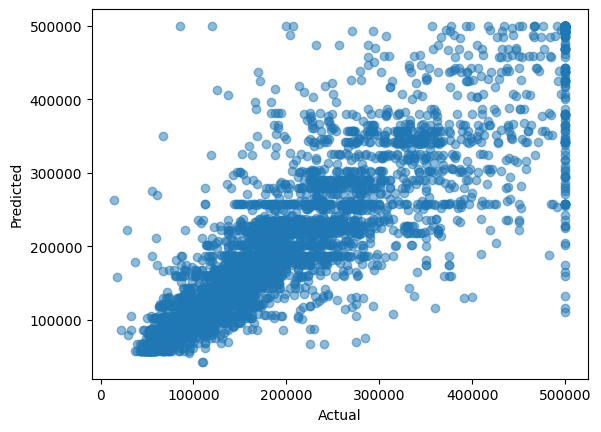

In [ ]:
plt.scatter(y_test,y_pred,alpha=0.5)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

## 9. Residual Analysis

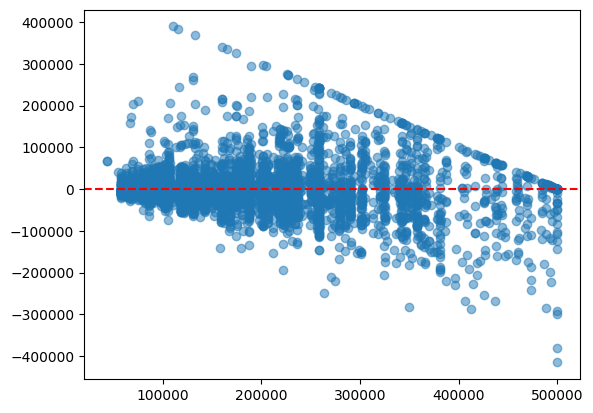

In [ ]:
res=y_test-y_pred
plt.scatter(y_pred,res,alpha=0.5)
plt.axhline(0,color='red',ls='--')
plt.show()

## 10. Feature Importance

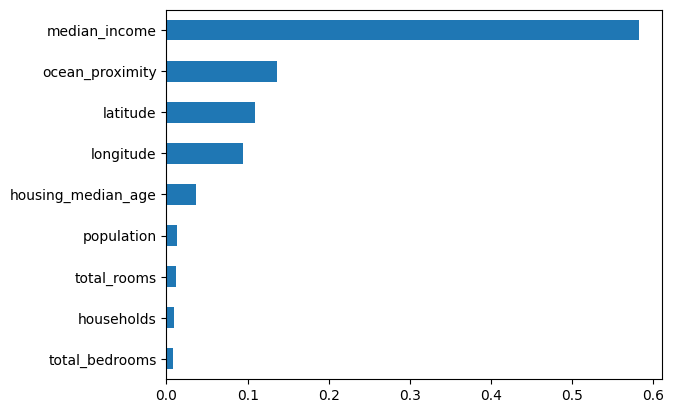

In [ ]:
import pandas as pd
fi=pd.Series(model.feature_importances_,index=X.columns).sort_values()
fi.plot(kind='barh')
plt.show()

## 11. Key Findings

- The Decision Tree Regressor successfully learned the relationship between housing features and median house values.
- The model achieved a good baseline R² Score, explaining approximately 71% of the variation in the target variable.
- Median income and geographical features were among the most influential predictors.
- Decision Trees can capture complex non-linear relationships but are prone to overfitting if their depth is not controlled.
- Regression models are evaluated using error-based metrics such as MAE, RMSE, and R² Score instead of classification accuracy.

## 12. Conclusion

This project demonstrated the implementation of a Decision Tree Regressor for predicting California housing prices. After preprocessing the dataset and encoding categorical features, the model was trained and evaluated using standard regression metrics. The results show that Decision Trees provide an intuitive and effective approach for regression tasks while emphasizing the importance of controlling model complexity to achieve good generalization performance.